# Modeling — Purchase Propensity

In this notebook, I'll:

- choose a main model after comparing several with default parameters
- tune hyperparameters, evaluate, and use calibration to get probabilities
- use on test set (untouched until last step) to get final output

The goal is to have purchase probabilities for each (user, category)-pair. The usable output from this is a ranked list of active users per category ordered by purchase propensity. The business framing is flexible; possible use cases include targeting top n users in a category for a campaign, push notifications, or a recommendation slot. The underlying assumption is that high-propensity users have higher expected return per contact than a random selection.

## Sections
1. Setup
2. Load Features
3. Validation Set
4. Model Comparison
5. LightGBM Hyperparameter Search
6. LightGBM Full CV
7. Evaluation
8. Calibration
9. Final Model & Test Predictions
10. Conclusion

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time, copy
from pathlib import Path

from sklearn.base import clone
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, log_loss, roc_curve
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
import lightgbm as lgb
import xgboost as xgb

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

FEATURES_DIR = Path('../data')
SEED         = 42
N_FOLDS      = 5
KEPT_CATS    = ['electronics', 'appliances', 'computers', 'furniture',
                'apparel', 'auto', 'construction', 'kids']

## 2. Load Features

In [2]:
train = pd.read_parquet(FEATURES_DIR / 'train_features.parquet')
test  = pd.read_parquet(FEATURES_DIR / 'test_features.parquet')

print(f'Train: {train.shape[0]:,} | positive rate: {train["label"].mean():.2%}')
print(f'Test:    {test.shape[0]:,} | positive rate: {test["label"].mean():.2%}')

Train: 1,395,712 | positive rate: 3.22%
Test:    348,928 | positive rate: 3.24%


## 3. Validation Set

I'll hold out 20% of training users as a labeled validation set before any modelling. These users are absent from every training fold, meant to measure generalization to completely unseen users. The test set is never touched until section 9.

The positive rate on val set will serve as an anchor; a well-calibrated model's mean predicted probability should match the positive rate on unseen data.

In [3]:
all_train_users = np.sort(train['user_id'].unique())
rng             = np.random.default_rng(SEED)
val_user_ids    = set(rng.choice(all_train_users, size=int(len(all_train_users) * 0.2), replace=False))

train_pool = train[~train['user_id'].isin(val_user_ids)].copy()
val_df     = train[ train['user_id'].isin(val_user_ids)].copy()

val_pos_rate = val_df['label'].mean()

print(f'{"Split":<15} {"users":>8}  {"rows":>10}  {"pos rate":>10}')
print('-' * 52)
print(f'{"train_pool":<15} {train_pool["user_id"].nunique():>8,}  {len(train_pool):>10,}  {train_pool["label"].mean():>10.2%}')
print(f'{"val_df":<15} {val_df["user_id"].nunique():>8,}  {len(val_df):>10,}  {val_df["label"].mean():>10.2%}')

Split              users        rows    pos rate
----------------------------------------------------
train_pool       139,572   1,116,576       3.23%
val_df            34,892     279,136       3.18%


## 4. Model Comparison

I'll compare several models with default hyperparameters to see which ones are worth pursuing. I'll exclude random forest here as gradient boosting options consistently perform better than a bagging ensemble on tabular data, and at this dataset's size the 5-fold cross-validation has a long runtime.

Two evaluation views:
1. OOF: 5-fold GroupKFold on `train_pool`, grouped by user so that all rows belonging to a user stay in the same fold, preventing leakage across the scaffold
2. On val set: Users held out entirely from training, measuring generalization to unseen users

We would expect a small gap between OOF and val, but a large gap signals overfitting to the train set that OOF alone would miss.

Comparing val mean prob vs val positive rate is also a quick first calibration check.

In [4]:
cat_cols = ['category_l1']
num_cols = [
    'views_30d', 'carts_30d', 'purchases_30d',
    'views_14d', 'carts_14d', 'purchases_14d',
    'views_7d', 'carts_7d', 'purchases_7d',
    'days_since_view', 'days_since_cart', 'days_since_purchase',
    'total_views_30d', 'total_carts_30d', 'total_purchases_30d',
    'active_days_30d', 'category_breadth_30d', 'session_count_30d',
    'cat_purchase_rate', 'cart_view_ratio_30d', 'cart_view_ratio_7d',
    'brand_count_30d',
    'avg_price_viewed_30d', 'avg_price_carted_30d',
]
feature_cols = num_cols + cat_cols

# LR: impute nulls with -1, scale numerics, OHE categoricals
lr_prep = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='constant', fill_value=-1)),
        ('scl', StandardScaler()),
    ]), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])

# Tree models (XGBoost, HistGBM): impute + OHE
tree_prep = ColumnTransformer([
    ('num', SimpleImputer(strategy='constant', fill_value=-1), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])

# train_pool arrays
X_pool_sk  = train_pool[feature_cols].copy()
X_pool_lgb = train_pool[feature_cols].copy()
for col in cat_cols:
    X_pool_lgb[col] = X_pool_lgb[col].astype('category')

y_pool      = train_pool['label']
groups_pool = train_pool['user_id']

# val arrays
X_val_sk  = val_df[feature_cols].copy()
X_val_lgb = val_df[feature_cols].copy()
for col in cat_cols:
    X_val_lgb[col] = X_val_lgb[col].astype('category')

y_val = val_df['label'].values
gkf   = GroupKFold(n_splits=N_FOLDS)

print(f'Features: {len(feature_cols)} ({len(num_cols)} numeric, {len(cat_cols)} categorical)')
print(f'train_pool: {len(X_pool_sk):,} rows | val_df: {len(X_val_sk):,} rows')

Features: 25 (24 numeric, 1 categorical)
train_pool: 1,116,576 rows | val_df: 279,136 rows


In [5]:
# Naive baseline: category purchase rate
cat_rates        = train_pool.groupby('category_l1')['label'].mean()
naive_pool_preds = train_pool['category_l1'].map(cat_rates).values
naive_val_preds  = val_df['category_l1'].map(cat_rates).fillna(cat_rates.mean()).values

results = {}
results['Naive Baseline'] = {
    'oof_auc':       roc_auc_score(y_pool, naive_pool_preds),
    'oof_logloss':   log_loss(y_pool, naive_pool_preds),
    'val_auc':       roc_auc_score(y_val,  naive_val_preds),
    'val_logloss':   log_loss(y_val,  naive_val_preds),
    'val_mean_prob': float(naive_val_preds.mean()),
    'time_s':        0.0,
}
r = results['Naive Baseline']
print(f'Naive Baseline')
print(f'OOF - AUC: {r["oof_auc"]:.4f}  LogLoss: {r["oof_logloss"]:.4f}')
print(f'Val - AUC: {r["val_auc"]:.4f}  LogLoss: {r["val_logloss"]:.4f}  MeanProb: {r["val_mean_prob"]:.4f}  (true: {val_pos_rate:.4f})')

Naive Baseline
OOF - AUC: 0.8699  LogLoss: 0.1061
Val - AUC: 0.8705  LogLoss: 0.1048  MeanProb: 0.0323  (true: 0.0318)


In [6]:
sklearn_models = {
    'Logistic Regression': Pipeline([
        ('prep', lr_prep),
        ('clf', LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)),
    ]),
    'HistGradientBoosting': Pipeline([
        ('prep', tree_prep),
        ('clf', HistGradientBoostingClassifier(
            max_iter=300, random_state=SEED,
        )),
    ]),
    'XGBoost': Pipeline([
        ('prep', tree_prep),
        ('clf', xgb.XGBClassifier(
            n_estimators=500, learning_rate=0.1, n_jobs=-1, random_state=SEED,
            eval_metric='logloss', early_stopping_rounds=50, verbosity=0,
        )),
    ]),
}

for name, pipeline in sklearn_models.items():
    print(f'\n{name}')
    print('-' * 50)
    oof = np.zeros(len(X_pool_sk))
    xgb_best_iters = []
    t0 = time.time()

    for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_pool_sk, y_pool, groups_pool)):
        if name == 'XGBoost':
            prep = clone(pipeline.named_steps['prep'])
            X_tr_t = prep.fit_transform(X_pool_sk.iloc[tr_idx])
            X_vl_t = prep.transform(X_pool_sk.iloc[val_idx])
            clf = clone(pipeline.named_steps['clf'])
            clf.fit(X_tr_t, y_pool.iloc[tr_idx],
                    eval_set=[(X_vl_t, y_pool.iloc[val_idx])], verbose=False)
            oof[val_idx] = clf.predict_proba(X_vl_t)[:, 1]
            xgb_best_iters.append(clf.best_iteration)
        else:
            p = clone(pipeline)
            p.fit(X_pool_sk.iloc[tr_idx], y_pool.iloc[tr_idx])
            oof[val_idx] = p.predict_proba(X_pool_sk.iloc[val_idx])[:, 1]

        print(f'Fold {fold}: AUC = {roc_auc_score(y_pool.iloc[val_idx], oof[val_idx]):.4f}')

    # Retrain on full train_pool for val predictions
    if name == 'XGBoost':
        mean_bi = int(np.mean(xgb_best_iters))
        prep = clone(pipeline.named_steps['prep'])
        X_pool_t = prep.fit_transform(X_pool_sk)
        X_val_t = prep.transform(X_val_sk)
        final = xgb.XGBClassifier(n_estimators=mean_bi, learning_rate=0.1,
                                n_jobs=-1, random_state=SEED, verbosity=0)
        final.fit(X_pool_t, y_pool)
        val_preds = final.predict_proba(X_val_t)[:, 1]
    else:
        final = clone(pipeline)
        final.fit(X_pool_sk, y_pool)
        val_preds = final.predict_proba(X_val_sk)[:, 1]

    elapsed = time.time() - t0
    results[name] = {
        'oof_auc':       roc_auc_score(y_pool, oof),
        'oof_logloss':   log_loss(y_pool, oof),
        'val_auc':       roc_auc_score(y_val, val_preds),
        'val_logloss':   log_loss(y_val, val_preds),
        'val_mean_prob': float(val_preds.mean()),
        'time_s':        elapsed,
    }
    r = results[name]
    print(f'OOF: AUC {r["oof_auc"]:.4f}  LL {r["oof_logloss"]:.4f}  |  '
          f'Val: AUC {r["val_auc"]:.4f}  LL {r["val_logloss"]:.4f}  '
          f'MeanProb {r["val_mean_prob"]:.4f}  |  {elapsed:.0f}s')


Logistic Regression
--------------------------------------------------
Fold 0: AUC = 0.9102
Fold 1: AUC = 0.9076
Fold 2: AUC = 0.9075
Fold 3: AUC = 0.9093
Fold 4: AUC = 0.9084
OOF: AUC 0.9086  LL 0.0892  |  Val: AUC 0.9095  LL 0.0877  MeanProb 0.0323  |  43s

HistGradientBoosting
--------------------------------------------------
Fold 0: AUC = 0.9461
Fold 1: AUC = 0.9459
Fold 2: AUC = 0.9460
Fold 3: AUC = 0.9449
Fold 4: AUC = 0.9444
OOF: AUC 0.9453  LL 0.0740  |  Val: AUC 0.9473  LL 0.0725  MeanProb 0.0319  |  63s

XGBoost
--------------------------------------------------
Fold 0: AUC = 0.9463
Fold 1: AUC = 0.9459
Fold 2: AUC = 0.9461
Fold 3: AUC = 0.9450
Fold 4: AUC = 0.9446
OOF: AUC 0.9455  LL 0.0739  |  Val: AUC 0.9473  LL 0.0724  MeanProb 0.0319  |  51s


In [7]:
# LightGBM - default params + native categorical + early stopping
lgb_oof_cmp = np.zeros(len(X_pool_lgb))
lgb_bi_cmp  = []
t0          = time.time()

print('LightGBM (default params)')
print('-' * 50)

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_pool_lgb, y_pool, groups_pool)):
    m = lgb.LGBMClassifier(n_estimators=1000, random_state=SEED, verbose=-1, n_jobs=-1)
    m.fit(
        X_pool_lgb.iloc[tr_idx], y_pool.iloc[tr_idx],
        eval_set=[(X_pool_lgb.iloc[val_idx], y_pool.iloc[val_idx])],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    lgb_oof_cmp[val_idx] = m.predict_proba(X_pool_lgb.iloc[val_idx])[:, 1]
    lgb_bi_cmp.append(m.best_iteration_)
    print(f'Fold {fold}: AUC = {roc_auc_score(y_pool.iloc[val_idx], lgb_oof_cmp[val_idx]):.4f}'
          f'(best_iter={m.best_iteration_})')

_mean_iter = int(np.mean(lgb_bi_cmp) * N_FOLDS / (N_FOLDS - 1))
_final     = lgb.LGBMClassifier(n_estimators=_mean_iter, random_state=SEED, verbose=-1, n_jobs=-1)
_final.fit(X_pool_lgb, y_pool)
val_preds_lgb_cmp = _final.predict_proba(X_val_lgb)[:, 1]

elapsed = time.time() - t0
results['LightGBM'] = {
    'oof_auc':       roc_auc_score(y_pool, lgb_oof_cmp),
    'oof_logloss':   log_loss(y_pool, lgb_oof_cmp),
    'val_auc':       roc_auc_score(y_val, val_preds_lgb_cmp),
    'val_logloss':   log_loss(y_val, val_preds_lgb_cmp),
    'val_mean_prob': float(val_preds_lgb_cmp.mean()),
    'time_s':        elapsed,
}
r = results['LightGBM']
print(f'\nOOF: AUC {r["oof_auc"]:.4f}  LL {r["oof_logloss"]:.4f}  |  '
      f'Val: AUC {r["val_auc"]:.4f}  LL {r["val_logloss"]:.4f}  '
      f'MeanProb {r["val_mean_prob"]:.4f}  |  {elapsed:.0f}s')

LightGBM (default params)
--------------------------------------------------
Fold 0: AUC = 0.9464(best_iter=96)
Fold 1: AUC = 0.9459(best_iter=78)
Fold 2: AUC = 0.9461(best_iter=77)
Fold 3: AUC = 0.9452(best_iter=60)
Fold 4: AUC = 0.9445(best_iter=109)

OOF: AUC 0.9456  LL 0.0739  |  Val: AUC 0.9471  LL 0.0725  MeanProb 0.0319  |  25s


Val positive rate (ground truth): 0.0318

               Model  OOF AUC  OOF LogLoss  Val AUC  Val LogLoss  Val MeanProb  Time (s)
             XGBoost   0.9455       0.0739   0.9473       0.0724        0.0319   51.3878
HistGradientBoosting   0.9453       0.0740   0.9473       0.0725        0.0319   63.0524
            LightGBM   0.9456       0.0739   0.9471       0.0725        0.0319   24.9114
 Logistic Regression   0.9086       0.0892   0.9095       0.0877        0.0323   43.4185
      Naive Baseline   0.8699       0.1061   0.8705       0.1048        0.0323    0.0000


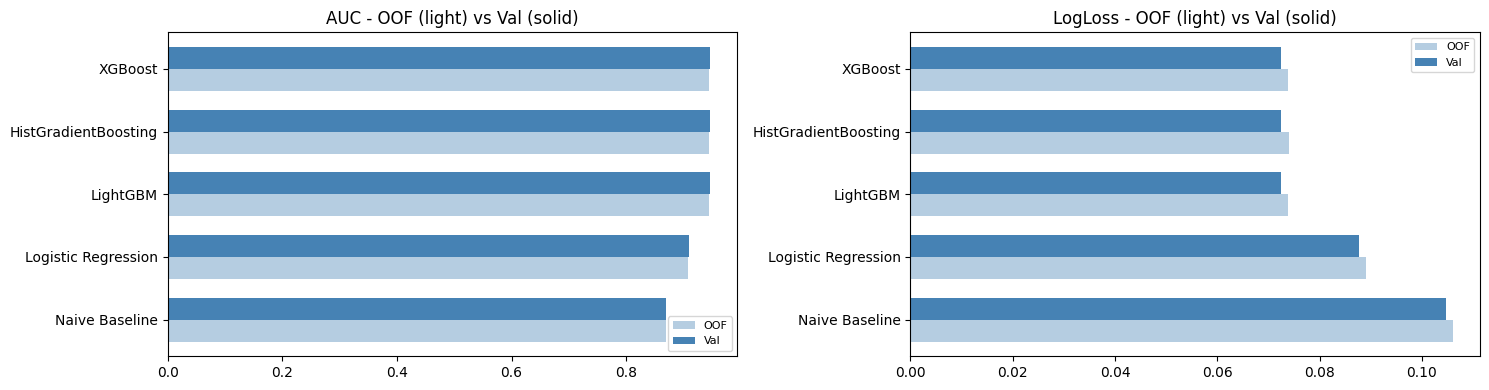

In [8]:
comparison = (
    pd.DataFrame([
        {'Model': name, 'OOF AUC': v['oof_auc'], 'OOF LogLoss': v['oof_logloss'],
         'Val AUC': v['val_auc'], 'Val LogLoss': v['val_logloss'],
         'Val MeanProb': v['val_mean_prob'], 'Time (s)': v['time_s']}
        for name, v in results.items()
    ])
    .sort_values('Val AUC', ascending=False)
    .reset_index(drop=True)
)

print(f'Val positive rate (ground truth): {val_pos_rate:.4f}\n')
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, max(4, len(comparison) * 0.6)))
plot_df = comparison.sort_values('Val AUC', ascending=True)
x, w = np.arange(len(plot_df)), 0.35

for ax, metric, title in [
    (axes[0], ('OOF AUC',     'Val AUC'),     'AUC - OOF (light) vs Val (solid)'),
    (axes[1], ('OOF LogLoss', 'Val LogLoss'), 'LogLoss - OOF (light) vs Val (solid)'),
]:
    ax.barh(x - w/2, plot_df[metric[0]], w, alpha=0.4, color='steelblue', label='OOF')
    ax.barh(x + w/2, plot_df[metric[1]], w, alpha=1.0, color='steelblue', label='Val')
    ax.set_yticks(x)
    ax.set_yticklabels(plot_df['Model'])
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

GBDT family performance seems consistent across models, I'll choose lightgbm as the main model for its speed. I'll keep logistic regression as the baseline as its linear boundary shows what user-level signal adds beyond category base rates.

## 5. LightGBM Hyperparameter Search

Here I'll do a random search over 20 parameter combinations using fold 0 only. Since fold 0 is the tuning fold, I'll exclude it from the OOF metrics in section 6.

Parameters searched: `num_leaves`, `min_child_samples`, `learning_rate`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`.

In [9]:
rng_hp  = np.random.default_rng(SEED)
N_SEARCH = 20

# Fold 0 only for HP search
_tr0, _vl0 = next(iter(gkf.split(X_pool_lgb, y_pool, groups_pool)))
X_hp_tr, X_hp_vl = X_pool_lgb.iloc[_tr0], X_pool_lgb.iloc[_vl0]
y_hp_tr, y_hp_vl = y_pool.iloc[_tr0],     y_pool.iloc[_vl0]

hp_results = []
print(f'HP random search: {N_SEARCH} trials (fold 0 only)')
print('-' * 60)

for i in range(N_SEARCH):
    trial = dict(
        num_leaves        = int(rng_hp.integers(15, 128)),
        min_child_samples = int(rng_hp.integers(20, 200)),
        learning_rate     = float(rng_hp.uniform(0.02, 0.15)),
        subsample         = float(rng_hp.uniform(0.6, 1.0)),
        colsample_bytree  = float(rng_hp.uniform(0.6, 1.0)),
        reg_alpha         = float(rng_hp.choice([0.0, 0.1, 0.5, 1.0])),
        reg_lambda        = float(rng_hp.choice([0.0, 0.1, 0.5, 1.0])),
    )
    m = lgb.LGBMClassifier(n_estimators=2000, random_state=SEED, verbose=-1, n_jobs=-1, **trial)
    m.fit(
        X_hp_tr, y_hp_tr,
        eval_set=[(X_hp_vl, y_hp_vl)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    auc = roc_auc_score(y_hp_vl, m.predict_proba(X_hp_vl)[:, 1])
    hp_results.append({'auc': auc, 'best_iter': m.best_iteration_, **trial})
    print(f'[{i+1:2d}] AUC={auc:.4f}  leaves={trial["num_leaves"]:3d}'
          f'  lr={trial["learning_rate"]:.3f}  iter={m.best_iteration_}')

hp_df      = pd.DataFrame(hp_results).sort_values('auc', ascending=False)
best_params = hp_df.iloc[0].drop(['auc', 'best_iter']).to_dict()
best_params['num_leaves']        = int(best_params['num_leaves'])
best_params['min_child_samples'] = int(best_params['min_child_samples'])

print(f'\nBest fold-0 AUC: {hp_df["auc"].iloc[0]:.4f}')
print(f'Best params: {best_params}')
hp_df.head(5)

HP random search: 20 trials (fold 0 only)
------------------------------------------------------------
[ 1] AUC=0.9465  leaves= 25  lr=0.077  iter=180
[ 2] AUC=0.9464  leaves= 74  lr=0.119  iter=53
[ 3] AUC=0.9463  leaves= 71  lr=0.140  iter=54
[ 4] AUC=0.9465  leaves= 65  lr=0.092  iter=67
[ 5] AUC=0.9466  leaves= 33  lr=0.066  iter=209
[ 6] AUC=0.9465  leaves=100  lr=0.081  iter=76
[ 7] AUC=0.9460  leaves=119  lr=0.146  iter=33
[ 8] AUC=0.9465  leaves=104  lr=0.037  iter=196
[ 9] AUC=0.9463  leaves=121  lr=0.128  iter=45
[10] AUC=0.9466  leaves= 64  lr=0.070  iter=101
[11] AUC=0.9464  leaves=109  lr=0.021  iter=297
[12] AUC=0.9466  leaves= 46  lr=0.080  iter=89
[13] AUC=0.9464  leaves= 64  lr=0.081  iter=89
[14] AUC=0.9464  leaves= 78  lr=0.093  iter=67
[15] AUC=0.9463  leaves=126  lr=0.073  iter=71
[16] AUC=0.9465  leaves=111  lr=0.058  iter=131
[17] AUC=0.9463  leaves=127  lr=0.073  iter=74
[18] AUC=0.9466  leaves= 26  lr=0.114  iter=149
[19] AUC=0.9461  leaves=120  lr=0.111  iter=

,auc,best_iter,num_leaves,min_child_samples,learning_rate,subsample,colsample_bytree,reg_alpha,reg_lambda
4,0.9466,209,33,156,0.0661,0.9883,0.9572,0.5000,1.0000
17,0.9466,149,26,36,0.1139,0.7848,0.6645,1.0000,0.5000
9,0.9466,101,64,164,0.0704,0.7153,0.8730,0.5000,0.0000
11,0.9466,89,46,160,0.0797,0.8275,0.6559,0.0000,0.0000
19,0.9465,97,92,133,0.0670,0.6351,0.6472,0.1000,1.0000


We see that the model is robust to hyperparameter changes; AUC spread across 20 trials was under 0.001.

## 6. LightGBM Full CV

I'll use 5-fold GroupKFold on `train_pool`. Fold 0 was the HP tuning fold, hence is excluded from the reported OOF metrics. Feature importances are averaged over all folds. After cross-validation, the model is retrained on all of `train_pool` using mean `n_estimators`.

In [10]:
lgb_params = dict(
    n_estimators=2000,
    random_state=SEED,
    verbose=-1,
    n_jobs=-1,
    **best_params,
)

lgb_oof          = np.zeros(len(X_pool_lgb))
lgb_scores       = []
best_iterations  = []
feat_importances = np.zeros(len(feature_cols))
fold0_val_idx    = None

print('LightGBM - GroupKFold CV')
print('-' * 50)

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_pool_lgb, y_pool, groups_pool)):
    if fold == 0:
        fold0_val_idx = val_idx

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_pool_lgb.iloc[tr_idx], y_pool.iloc[tr_idx],
        eval_set=[(X_pool_lgb.iloc[val_idx], y_pool.iloc[val_idx])],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    preds = model.predict_proba(X_pool_lgb.iloc[val_idx])[:, 1]
    lgb_oof[val_idx] = preds
    best_iterations.append(model.best_iteration_)
    feat_importances += model.feature_importances_

    auc = roc_auc_score(y_pool.iloc[val_idx], preds)
    ll  = log_loss(y_pool.iloc[val_idx], preds)
    lgb_scores.append({'fold': fold, 'auc': auc, 'logloss': ll, 'best_iter': model.best_iteration_})
    print(f'Fold {fold}: AUC={auc:.4f}  LogLoss={ll:.4f}  best_iter={model.best_iteration_}')

feat_importances /= N_FOLDS

# Reported metrics: folds 1-4 only (fold 0 excluded as HP tuning fold)
eval_mask            = np.ones(len(X_pool_lgb), dtype=bool)
eval_mask[fold0_val_idx] = False
reported_auc         = roc_auc_score(y_pool[eval_mask], lgb_oof[eval_mask])
reported_ll          = log_loss(y_pool[eval_mask], lgb_oof[eval_mask])

mean_iters = int(np.round(np.mean(best_iterations)))

print(f'\nReported OOF AUC (folds 1-4): {reported_auc:.4f}  |  LogLoss: {reported_ll:.4f}')
print(f'Best iterations: {best_iterations}')
print(f'mean_iters (used for retraining): {mean_iters}')

LightGBM - GroupKFold CV
--------------------------------------------------
Fold 0: AUC=0.9466  LogLoss=0.0736  best_iter=209
Fold 1: AUC=0.9461  LogLoss=0.0742  best_iter=170
Fold 2: AUC=0.9463  LogLoss=0.0741  best_iter=153
Fold 3: AUC=0.9452  LogLoss=0.0737  best_iter=114
Fold 4: AUC=0.9447  LogLoss=0.0729  best_iter=148

Reported OOF AUC (folds 1-4): 0.9455  |  LogLoss: 0.0737
Best iterations: [209, 170, 153, 114, 148]
mean_iters (used for retraining): 159


In [11]:
# Retrain on full train_pool for val predictions
final_params = {**lgb_params, 'n_estimators': mean_iters}
final_lgb    = lgb.LGBMClassifier(**final_params)
final_lgb.fit(X_pool_lgb, y_pool)

val_preds_lgb = final_lgb.predict_proba(X_val_lgb)[:, 1]
val_auc_lgb   = roc_auc_score(y_val, val_preds_lgb)
val_ll_lgb    = log_loss(y_val, val_preds_lgb)

print(f'Val AUC:      {val_auc_lgb:.4f}')
print(f'Val LogLoss:  {val_ll_lgb:.4f}')
print(f'Val MeanProb: {val_preds_lgb.mean():.4f}  (true val rate: {val_pos_rate:.4f})')

Val AUC:      0.9474
Val LogLoss:  0.0723
Val MeanProb: 0.0319  (true val rate: 0.0318)


## 7. Evaluation

### 7.1 Per-Category AUC

In this section I'll break down AUC by category with lightgbm vs logistic regression side by side. We'll observe:

- categories where both models score similarly have low data volume
- categories with a large LGB–LR gap are where non-linear feature interactions are paying off

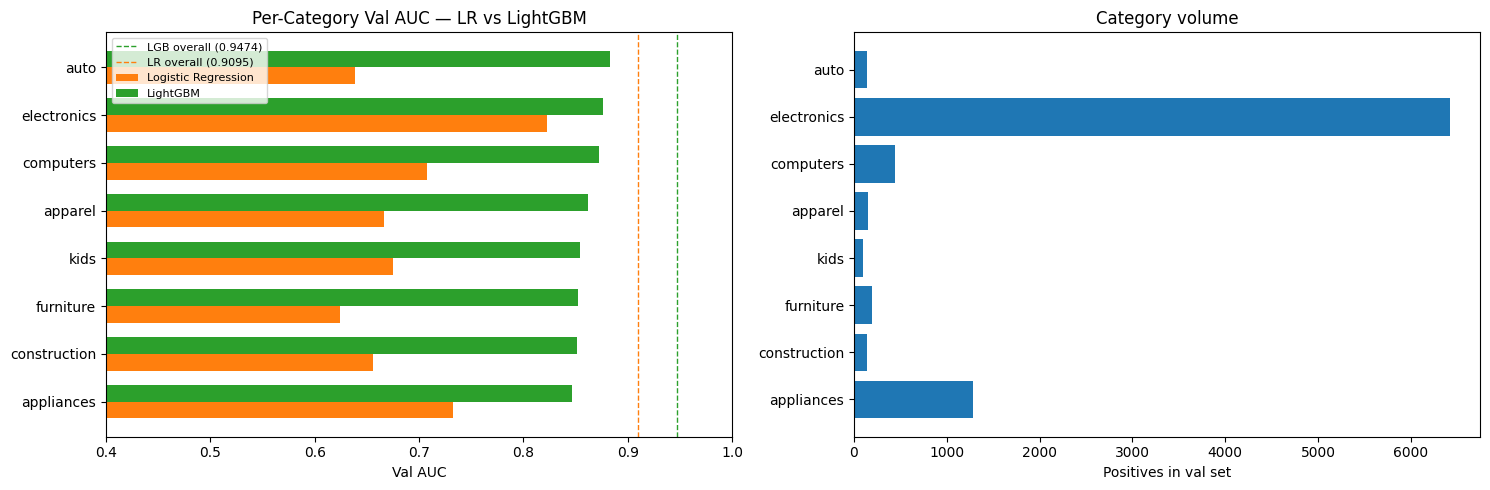

    category  n_pos  pos_rate  LR Val AUC  LGB Val AUC  delta
  appliances   1283    0.0368      0.7329       0.8465 0.1136
construction    141    0.0040      0.6558       0.8516 0.1958
   furniture    198    0.0057      0.6245       0.8519 0.2274
        kids     97    0.0028      0.6752       0.8547 0.1795
     apparel    154    0.0044      0.6668       0.8617 0.1948
   computers    445    0.0128      0.7080       0.8728 0.1648
 electronics   6425    0.1841      0.8229       0.8767 0.0537
        auto    138    0.0040      0.6382       0.8833 0.2451


In [12]:
# LR val predictions for comparison
lr_final = clone(sklearn_models['Logistic Regression'])
lr_final.fit(X_pool_sk, y_pool)
val_preds_lr = lr_final.predict_proba(X_val_sk)[:, 1]

cat_eval = []
for cat in KEPT_CATS:
    mask = val_df['category_l1'] == cat
    y_cat = y_val[mask.values]
    if len(np.unique(y_cat)) < 2:
        continue
    cat_eval.append({
        'category':    cat,
        'n_pos':       int(y_cat.sum()),
        'pos_rate':    y_cat.mean(),
        'LR Val AUC':  roc_auc_score(y_cat, val_preds_lr[mask.values]),
        'LGB Val AUC': roc_auc_score(y_cat, val_preds_lgb[mask.values]),
    })

cat_df = (
    pd.DataFrame(cat_eval)
    .assign(delta=lambda d: d['LGB Val AUC'] - d['LR Val AUC'])
    .sort_values('LGB Val AUC', ascending=True)
)

lr_overall_auc = results['Logistic Regression']['val_auc']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
y_pos = np.arange(len(cat_df))
w     = 0.35

axes[0].barh(y_pos - w/2, cat_df['LR Val AUC'],  w, color='tab:orange', label='Logistic Regression')
axes[0].barh(y_pos + w/2, cat_df['LGB Val AUC'], w, color='tab:green',  label='LightGBM')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(cat_df['category'])
axes[0].axvline(val_auc_lgb,    color='tab:green',  linestyle='--', lw=1, label=f'LGB overall ({val_auc_lgb:.4f})')
axes[0].axvline(lr_overall_auc, color='tab:orange', linestyle='--', lw=1, label=f'LR overall ({lr_overall_auc:.4f})')
axes[0].set_xlabel('Val AUC')
axes[0].set_title('Per-Category Val AUC — LR vs LightGBM')
axes[0].set_xlim(0.4, 1.0)
axes[0].legend(fontsize=8, loc='upper left')

axes[1].barh(y_pos, cat_df['n_pos'], color='tab:blue')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(cat_df['category'])
axes[1].set_xlabel('Positives in val set')
axes[1].set_title('Category volume')

plt.tight_layout()
plt.show()

print(cat_df.to_string(index=False))

### 7.2 Feature Importance

Split importance counts how often a feature is used for a tree split, averaged across CV folds. It measures usage frequency, not effect magnitude, so a feature that appears in many shallow splits can rank high without having a large per-prediction impact.

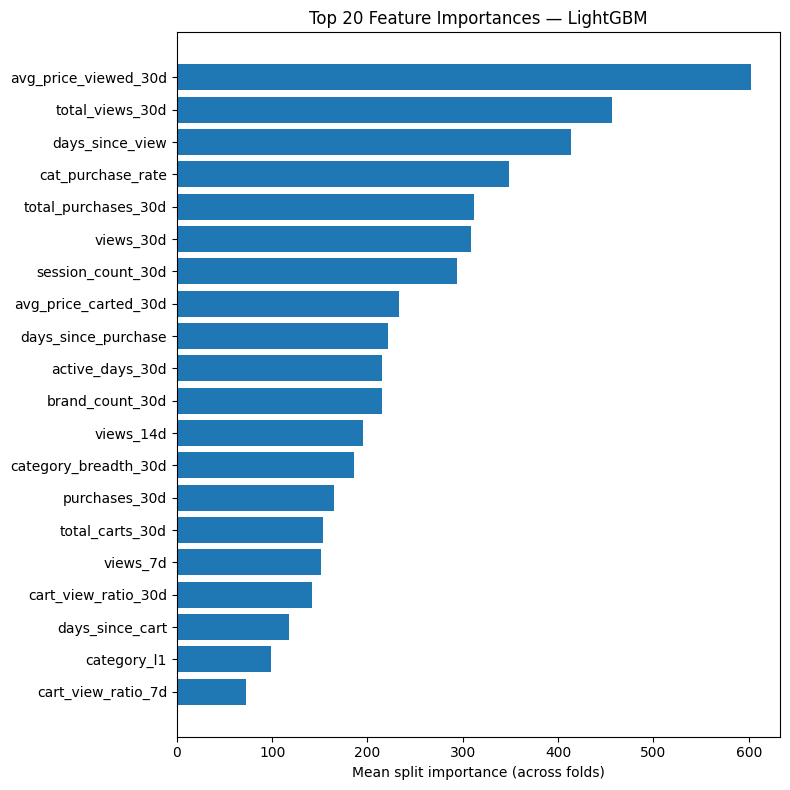

Top 10 features:
             feature  importance
avg_price_viewed_30d    602.6000
     total_views_30d    456.8000
     days_since_view    413.6000
   cat_purchase_rate    348.4000
 total_purchases_30d    311.4000
           views_30d    308.4000
   session_count_30d    294.4000
avg_price_carted_30d    232.6000
 days_since_purchase    221.8000
     active_days_30d    215.4000


In [13]:
imp_df = (
    pd.DataFrame({'feature': feature_cols, 'importance': feat_importances})
    .sort_values('importance', ascending=False)
)

top20 = imp_df.head(20).sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top20['feature'], top20['importance'], color='tab:blue')
ax.set_xlabel('Mean split importance (across folds)')
ax.set_title('Top 20 Feature Importances — LightGBM')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(imp_df.head(10).to_string(index=False))

## 8. Calibration

Raw lightgbm scores are rankings for purchase likelihood, not probabilities directly. In this section I'll use isotonic calibration to map them to probabilities, which makes expected value calculations possible (for instance, revenue = propensity x average order value per category).

The calibrator is fitted on validation set predictions from `final_lgb` (the model trained on `train_pool`) which ensures the calibration is done on unseen data.

The reliability diagram after calibration will look near-perfect, this is expected, not a validation result. Isotonic regression non-parametrically fits any monotone function on its training data, so the in-sample diagram is guaranteed to look good. The benefit is on the test predictions in the next section.

Our main model is already quite well-calibrated on the val set (val mean prob: 0.0320, pos rate: 0.0318). We see this in the reliability diagram before calibration as well, there is very small deviation from the diagonal.

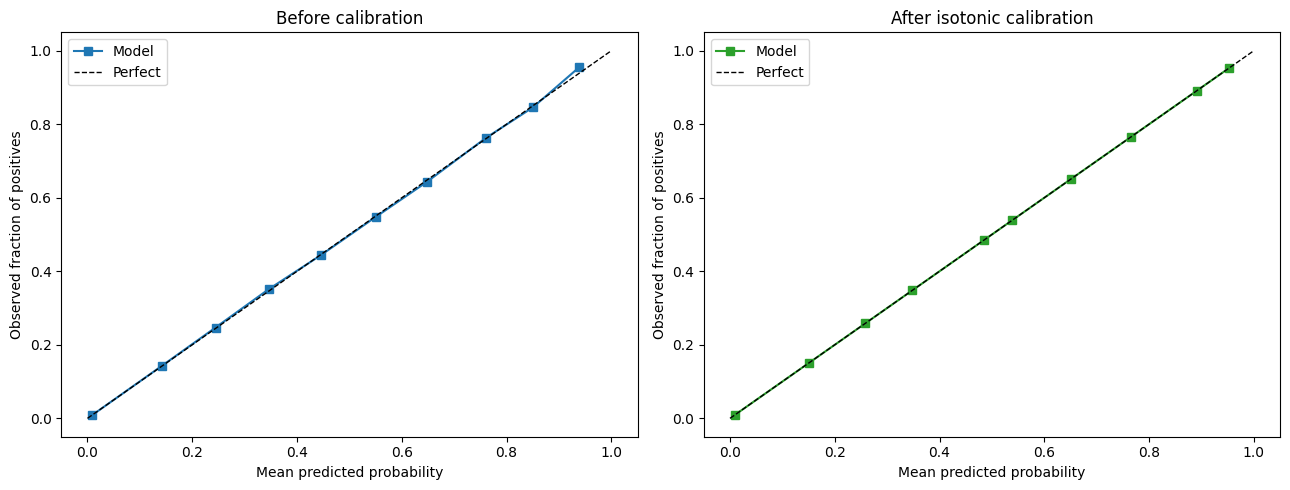

Val LogLoss - raw: 0.0723  |  calibrated: 0.0720


In [14]:
calibrator = IsotonicRegression(out_of_bounds='clip')
calibrator.fit(val_preds_lgb, y_val)

val_preds_cal = calibrator.predict(val_preds_lgb)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, title, color in [
    (axes[0], val_preds_lgb, 'Before calibration', 'tab:blue'),
    (axes[1], val_preds_cal, 'After isotonic calibration', 'tab:green'),
]:
    frac_pos, mean_pred = calibration_curve(y_val, preds, n_bins=10, strategy='uniform')
    ax.plot(mean_pred, frac_pos, 's-', color=color, label='Model')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Observed fraction of positives')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

print(f'Val LogLoss - raw: {log_loss(y_val, val_preds_lgb):.4f}  |  calibrated: {log_loss(y_val, val_preds_cal):.4f}')

## 9. Final Model & Test Predictions

The final model is retrained on the full labeled dataset (`train_pool` + `val_df`) using `mean_iters`. The isotonic calibrator from section 8 is applied to the test scores.

Note that the calibrator was fitted on `final_lgb` predictions (trained on `train_pool`, 80% of users) but is applied to `full_model` predictions (trained on all of `train`). `full_model`, trained on more data, has a different score distribution and may produce more extreme scores, making the calibrator slightly out of domain at test time. I'll ignore this gap as the data increment is small in ratio.

In [15]:
X_full_lgb = train[feature_cols].copy()
y_full     = train['label']
for col in cat_cols:
    X_full_lgb[col] = X_full_lgb[col].astype('category')

X_test_lgb = test[feature_cols].copy()
for col in cat_cols:
    X_test_lgb[col] = X_test_lgb[col].astype('category')

full_params = {**lgb_params, 'n_estimators': mean_iters}
full_model  = lgb.LGBMClassifier(**full_params)
full_model.fit(X_full_lgb, y_full)

test_preds_raw = full_model.predict_proba(X_test_lgb)[:, 1]
test_preds     = calibrator.predict(test_preds_raw)

print(f'Final model: {mean_iters} trees')
print(f'Test predictions (calibrated) — min: {test_preds.min():.4f}  median: {np.median(test_preds):.4f}  max: {test_preds.max():.4f}')
print(f'Mean predicted probability: {test_preds.mean():.4f}  (train positive rate: {y_full.mean():.4f})')

Final model: 159 trees
Test predictions (calibrated) — min: 0.0000  median: 0.0020  max: 1.0000
Mean predicted probability: 0.0322  (train positive rate: 0.0322)


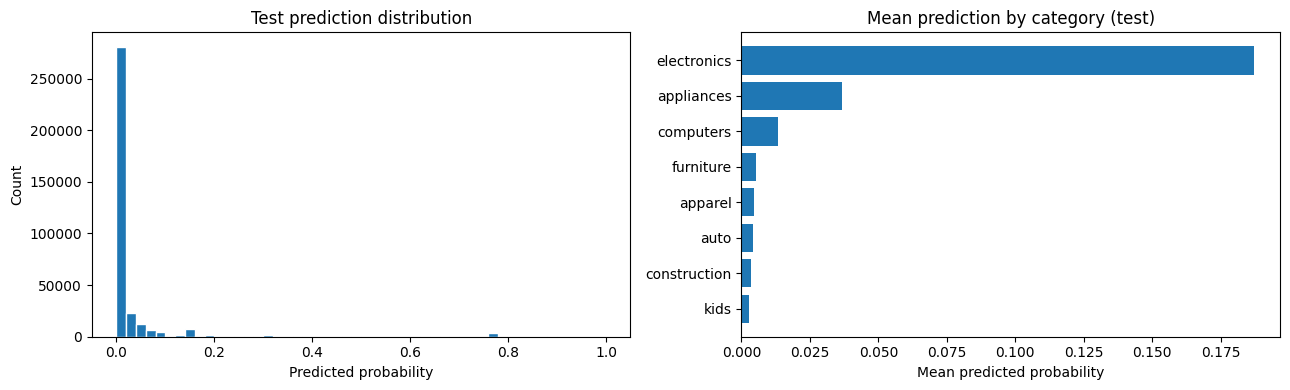

Output shape: (348928, 3)


,user_id,category_l1,propensity_score
28626,512437914,apparel,0.7662
61690,559930324,apparel,0.6802
71954,536711774,apparel,0.6802
204698,547066883,apparel,0.6802
38034,532509330,apparel,0.6591
38674,514068500,apparel,0.6543
48690,512393077,apparel,0.6543
65018,544375839,apparel,0.6543
66586,559499344,apparel,0.6543
80490,560914255,apparel,0.6543


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(test_preds, bins=50, edgecolor='white', color='tab:blue')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Test prediction distribution')

cat_means = (
    pd.DataFrame({'category': test['category_l1'], 'prob': test_preds})
    .groupby('category')['prob'].mean()
    .sort_values()
)
axes[1].barh(cat_means.index, cat_means.values, color='tab:blue')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_title('Mean prediction by category (test)')

plt.tight_layout()
plt.show()

output = test[['user_id', 'category_l1']].copy()
output['propensity_score'] = test_preds
output = output.sort_values(['category_l1', 'propensity_score'], ascending=[True, False])
print(f'Output shape: {output.shape}')
output.head(10)

In [17]:
output.to_parquet(FEATURES_DIR / 'test_predictions.parquet', index=False)
print('Saved: test_predictions.parquet')

Saved: test_predictions.parquet


## 10. Conclusion

We have built a calibrated lightgbm purchase propensity model for (user, category)-pairs. Output values are calibrated probabilities, enabling expected value calculations (for instance, expected revenue = propensity x average order value) or direct use as input to targeting logic.

### Key findings

- Naive baseline of category purchase rates already gives a solid start at 0.87 val AUC, reflecting the strong category-based signal in purchase behavior. Moving to logistic regression adds user-level signal, and lightgbm captures non-linear interactions and gives the best overall performance.

| Model | OOF AUC | Val AUC | Val LogLoss |
|---|---|---|---|
| LightGBM | 0.9456 | 0.9471 | 0.0725 |
| Logistic Regression | 0.9086 | 0.9095 | 0.0877 |
| Naive Baseline | 0.8699 | 0.8705 | 0.1048 |

- LGB is robust to hyperparameter changes; AUC change across 20 random search trials was under 0.001. The dataset's signal is strong enough that parameter sensitivity is low.

- Price features lead in feature importance; `avg_price_viewed_30d` is the top feature by a notable margin, with `avg_price_carted_30d` also in the top 10. These features capture the user's price segment, which is predictive of category-level purchase propensity. Cross-category activity (`total_views_30d`, `total_purchases_30d`, `session_count_30d`) ranks above category-specific counts, suggesting that overall engagement level generalizes well across categories. One would guess cart activity points to purchase intent, but surprisingly, category-specific cart counts (`carts_30d`, `carts_7d`) are among the weakest features.

- The model is already close in expectation before calibration (val mean prob 0.0320, val pos rate 0.0318). Isotonic regression corrects the small bin-level deviations visible in the reliability diagram.

### Up next: Negative sampling experiment

As a next step, I'll compare the full scaffold (purchasers + non-purchasers, ~3.2% positive rate) against a purchaser-only scaffold (~13% positive rate), evaluated on the same val set. This tests whether scaffold choice is a training data question or a model capacity one.